# Brain Tumor Classification using PCA + XGBoost

In this notebook, Principal Component Analysis (PCA) is used to reduce the dimensionality of the MRI image features before training an XGBoost classifier.
The objective is to study whether dimensionality reduction improves classification performance and computational efficiency.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

print("Libraries imported successfully.")

Libraries imported successfully.


## Define Dataset Paths

The Brain Tumor dataset is loaded from the training directory.
The same dataset and preprocessing strategy used in the previous experiments are retained to ensure fair comparison.

In [2]:
train_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-1(BrainTumour-SVM)/archive/Training"

classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

print("Classes Loaded:")
for cls in classes:
    print("-", cls)

Classes Loaded:
- no_tumor
- pituitary_tumor
- glioma_tumor
- meningioma_tumor


## Load and Preprocess the Dataset

Images are converted to grayscale, resized to 200×200 pixels, normalized, and flattened into feature vectors.
The resulting feature matrix will be used as input for PCA.

In [3]:
X = []
Y = []

for cls, label in classes.items():

    folder_path = os.path.join(train_path, cls)

    for filename in os.listdir(folder_path):

        image_path = os.path.join(folder_path, filename)

        img = cv2.imread(image_path, 0)

        if img is None:
            continue

        img = cv2.resize(img, (200, 200))

        X.append(img.flatten() / 255.0)
        Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("Feature Matrix Shape:", X.shape)
print("Label Vector Shape:", Y.shape)

Feature Matrix Shape: (2870, 40000)
Label Vector Shape: (2870,)


## Split the Dataset

The dataset is divided into training and testing sets using an 80-20 split.
The same split strategy as the previous experiments is used to ensure fair comparison.

In [4]:
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=10,
    stratify=Y
)

print("Training Samples:", len(xtrain))
print("Testing Samples:", len(xtest))

Training Samples: 2296
Testing Samples: 574


## Apply PCA for Dimensionality Reduction

Principal Component Analysis (PCA) is applied to reduce the dimensionality of the image feature vectors while retaining 98% of the variance present in the original dataset.
This reduces the number of input features before training the XGBoost classifier.

In [5]:
pca = PCA(n_components=0.98)

pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

print("Original Features :", xtrain.shape[1])
print("Reduced Features  :", pca_train.shape[1])

Original Features : 40000
Reduced Features  : 1299


## Train the PCA + XGBoost Model

The PCA-transformed feature vectors are used to train an XGBoost classifier.
The resulting model is evaluated and compared with the Original XGBoost approach.

In [6]:
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    random_state=10,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1
)

xgb_model.fit(pca_train, ytrain)

print("Model training completed.")

Model training completed.


## Evaluate the PCA + XGBoost Model

The trained model is evaluated on both the training and testing datasets.
The results are compared with the Original XGBoost approach to study the impact of dimensionality reduction.

In [7]:
train_accuracy = xgb_model.score(pca_train, ytrain)
test_accuracy = xgb_model.score(pca_test, ytest)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Testing Accuracy: 0.8031


## Classification Metrics

Predictions are generated for the testing dataset and detailed classification metrics are calculated for each tumor category.

In [8]:
y_pred = xgb_model.predict(pca_test)

print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.47      0.61        79
           1       0.83      0.97      0.90       165
           2       0.85      0.80      0.82       165
           3       0.71      0.80      0.75       165

    accuracy                           0.80       574
   macro avg       0.82      0.76      0.77       574
weighted avg       0.81      0.80      0.80       574



## Evaluation Metrics

Accuracy, weighted F1-score, sensitivity, specificity, and the confusion matrix are calculated to evaluate the PCA + XGBoost model.

In [9]:
accuracy = accuracy_score(ytest, y_pred)

f1 = f1_score(
    ytest,
    y_pred,
    average='weighted'
)

sensitivity = recall_score(
    ytest,
    y_pred,
    average='weighted'
)

cm = confusion_matrix(ytest, y_pred)

specificity_per_class = []

for i in range(len(cm)):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - (tp + fn + fp)

    specificity_per_class.append(
        tn / (tn + fp)
    )

specificity = np.mean(specificity_per_class)

print(f"Accuracy    : {accuracy*100:.2f}%")
print(f"F1 Score    : {f1*100:.2f}%")
print(f"Sensitivity : {sensitivity*100:.2f}%")
print(f"Specificity : {specificity*100:.2f}%")

Accuracy    : 80.31%
F1 Score    : 79.58%
Sensitivity : 80.31%
Specificity : 93.15%


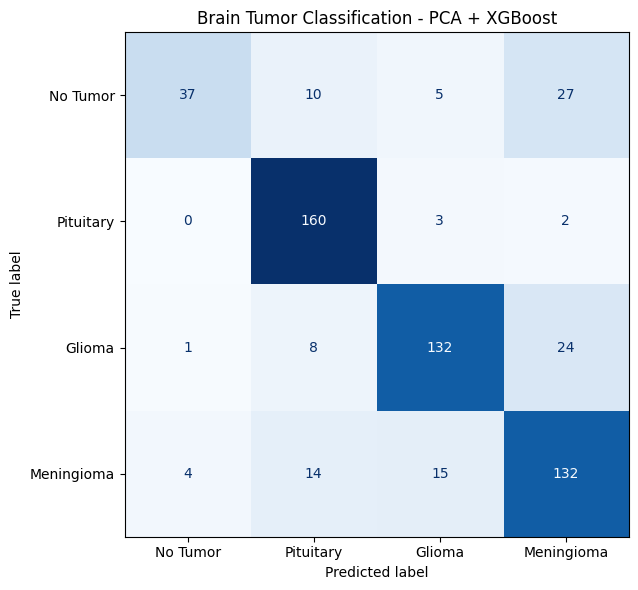

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(ytest, y_pred)

class_names = [
    "No Tumor",
    "Pituitary",
    "Glioma",
    "Meningioma"
]

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Brain Tumor Classification - PCA + XGBoost")
plt.tight_layout()
plt.show()

## Training Percentage Experiment

To study the effect of training data size, the PCA + XGBoost model is trained using 20%, 40%, 60%, and 80% of the original training set.
The same testing set is used throughout all experiments to ensure fair comparison.

In [11]:
training_sizes = [0.2, 0.4, 0.6, 0.8]

pca_xgb_train_scores = []
pca_xgb_test_scores = []

## Train PCA + XGBoost Using Different Training Sizes

For each training percentage, PCA is fitted on the training subset and then used to transform both the training and testing data.
An XGBoost classifier is trained on the reduced feature space and evaluated on the same testing set.

In [12]:
for size in training_sizes:

    x_small, _, y_small, _ = train_test_split(
        xtrain,
        ytrain,
        train_size=size,
        random_state=10,
        stratify=ytrain
    )

    # Apply PCA
    pca = PCA(n_components=0.98)

    pca_train = pca.fit_transform(x_small)
    pca_test = pca.transform(xtest)

    # Train XGBoost
    xgb_model = XGBClassifier(
        objective='multi:softmax',
        num_class=4,
        random_state=10,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1
    )

    xgb_model.fit(pca_train, y_small)

    train_acc = xgb_model.score(pca_train, y_small)
    test_acc = xgb_model.score(pca_test, ytest)

    pca_xgb_train_scores.append(train_acc)
    pca_xgb_test_scores.append(test_acc)

    print(f"\nTraining Size: {int(size * 100)}%")
    print(f"Samples: {len(x_small)}")
    print(f"PCA Features: {pca_train.shape[1]}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")


Training Size: 20%
Samples: 459
PCA Features: 358
Training Accuracy: 1.0000
Testing Accuracy: 0.6882

Training Size: 40%
Samples: 918
PCA Features: 650
Training Accuracy: 1.0000
Testing Accuracy: 0.7143

Training Size: 60%
Samples: 1377
PCA Features: 890
Training Accuracy: 1.0000
Testing Accuracy: 0.7456

Training Size: 80%
Samples: 1836
PCA Features: 1105
Training Accuracy: 1.0000
Testing Accuracy: 0.7683


## Accuracy vs Training Percentage

The relationship between training data size and PCA + XGBoost performance is visualized to study the effect of additional training samples.

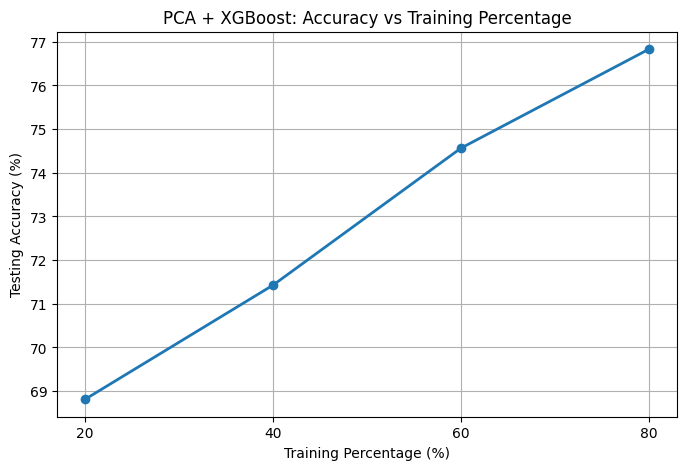

In [13]:
import matplotlib.pyplot as plt

percentages = [20, 40, 60, 80]

plt.figure(figsize=(8, 5))

plt.plot(
    percentages,
    [score * 100 for score in pca_xgb_test_scores],
    marker='o',
    linewidth=2
)

plt.title("PCA + XGBoost: Accuracy vs Training Percentage")
plt.xlabel("Training Percentage (%)")
plt.ylabel("Testing Accuracy (%)")
plt.xticks(percentages)
plt.grid(True)

plt.show()